--- ANALYTIC RESULTS ---
Initial Kinetic Energy of block:        40.00 J
Spring displacement: 0.2000 m

Calculated Work done ON the block: -40.00 J
(Note: Work is negative because Force opposes Displacement)

Calculated Work done ON the spring: 40.00 J
--- NUMERICAL RESULTS ---
Calculated Work done ON the BLOCK: -40.00 J
(Note: Work is negative because Force opposes Displacement)



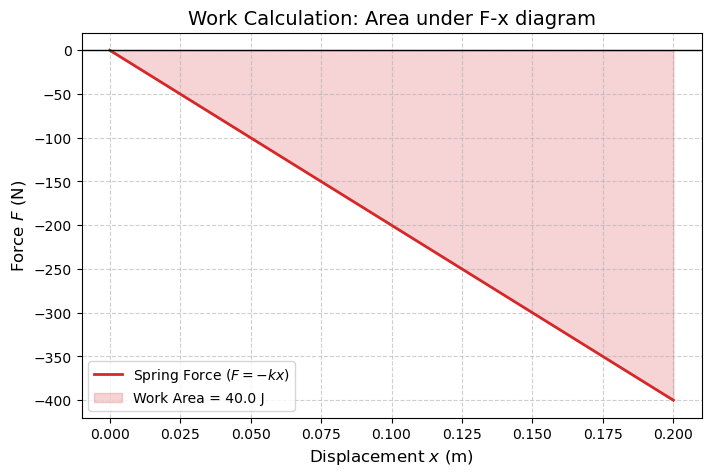

In [5]:
#| label: calc-work-spring
#| echo: true

import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# LECTURE 2: SYSTEMS, BOUNDARIES & OTHER BASICS
# Script: Spring Work Calculation
# Author: Edward Maginn, CBE 20260
# Description: 
#   This script models a block stopping against a spring. It demonstrates:
#   1. Analytic solution using conservation of energy.
#   2. Numerical solution using integration (work = integral of F dot dx).
#   3. Visualization of the work as the area under the force-displacement curve.
# ==============================================================================

# --- 1. System Parameters ---
m_kg = 5.0       # Mass of the moving block in kg - note units appended to variable name
v_ms = 4.0       # Initial velocity of the block, m/s
k_Nm = 2000.0    # Spring constant, N= kg m/s^2

# --- 2. Analytic Solution (Conservation of Energy) ---
# We assume all Kinetic Energy (KE) is converted to Elastic Potential Energy (PE).
# KE_initial = 1/2 * m * v^2
KE_initial_J = 0.5 * m_kg * v_ms**2 # J = kg m^2/s^2

# Solve for max displacement (x_max): 1/2 * k * x^2 = KE_initial
x_max_m = np.sqrt(KE_initial_J * 2 / k_Nm)

# Solve for the work =\int F dx analytically:
# W = - (1/2) k_NM x^2 | from 0 to x_max 
# The negative sign indicates work done on the block is negative (energy lost by block)
W_block_analytic_J = -0.5 * k_Nm * x_max_m**2

# Work on spring would be positive, equal in magnitude but opposite in sign:
# W_spring_analytic_J = +0.5 * k_Nm * x_max_m**2
W_spring_analytic_J = 0.5 * k_Nm * x_max_m**2 # Note force on spring is opposite to force on block

print(f"--- ANALYTIC RESULTS ---")
print(f"Initial Kinetic Energy of block:        {KE_initial_J:.2f} J")
print(f"Spring displacement: {x_max_m:.4f} m\n")
print(f"Calculated Work done ON the block: {W_block_analytic_J:.2f} J")
print(f"(Note: Work is negative because Force opposes Displacement)\n")
print(f"Calculated Work done ON the spring: {W_spring_analytic_J:.2f} J")

# --- 3. Numerical Solution (Work Definition) ---
# Create an array of position values from 0 to x_max
x_m = np.linspace(0, x_max_m, 100)

# Define Force at every point. 
# Note: Force is NEGATIVE because the spring pushes back (opposes motion).
F_spring_N = -k_Nm * x_m  

# Calculate Work by integrating Force over distance: W = ∫ F dx
# We use the trapezoidal rule for numerical integration.
W_block_J = np.trapezoid(F_spring_N, x_m)

print(f"--- NUMERICAL RESULTS ---")
print(f"Calculated Work done ON the BLOCK: {W_block_J:.2f} J")
print(f"(Note: Work is negative because Force opposes Displacement)\n")


# --- 4. Visualization ---
plt.figure(figsize=(8, 5))

# A. Plot the Force line
plt.plot(x_m, F_spring_N, color='#d62728', linewidth=2, label='Spring Force ($F=-kx$)')

# B. Shade the area representing Work
# This visually connects the integral (area) to the physical Work.
plt.fill_between(x_m, F_spring_N, color='#d62728', alpha=0.2, 
                 label=f'Work Area = {abs(W_block_J):.1f} J')

# C. Formatting for clarity
plt.axhline(0, color='black', linewidth=1) # Zero line for reference
plt.xlabel('Displacement $x$ (m)', fontsize=12)
plt.ylabel('Force $F$ (N)', fontsize=12)
plt.title('Work Calculation: Area under F-x diagram', fontsize=14)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()